In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
from tqdm import tqdm
plt.style.use(['science','no-latex'])
colors = ["#1982c4", "black", "#ff595e", "#20b806"]

### Compare X and Y trajectories for three vs four well cases

In [5]:
traj_three_states = pickle.load(
    open("/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb")
)
traj_three_states_z = pickle.load(
    open("/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/pickles_traj/seed1_N2500_dt0.01_samplingdt1000_nsteps5000000_frict1_temp1.p","rb")
)

print(traj_three_states.shape, traj_three_states_z.shape)

(1000, 2500, 2) (5000, 2500, 3)


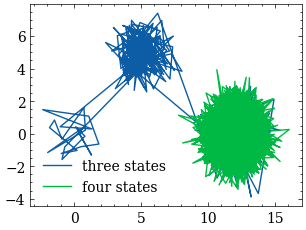

In [6]:
itraj = 21

plt.plot(traj_three_states[:,itraj,0], traj_three_states[:,itraj,1], label="three states")
plt.plot(traj_three_states_z[:,itraj,0], traj_four_states_long[:,itraj,1], label="four states")
plt.legend()
plt.show()

### Compare autocorrelation functions

In [7]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

In [8]:
traj_three_states = pickle.load(
    open("/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_traj/seed1_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb")
)
traj_three_states_z = pickle.load(
    open("/scratch/vdeltatt/imbalance-gain-causality/langevin/four_minima/pickles_traj/seed1_N2500_dt0.01_samplingdt1000_nsteps5000000_frict1_temp1.p","rb")
)

print(traj_three_states.shape, traj_three_states_z.shape)

(1000, 2500, 2) (5000, 2500, 3)


In [11]:
ntrajs = 2500
tau_max_three = 400
tau_max_threeZ = 2000

acfs_three = np.zeros((ntrajs,tau_max_three))
acfs_threeZ = np.zeros((ntrajs,tau_max_threeZ))

for itraj in tqdm(range(ntrajs)):
    acfs_three[itraj] = autocorr2(traj_three_states[100:,itraj,0])[:tau_max_three]
    acfs_threeZ[itraj] = autocorr2(traj_three_states_z[100:,itraj,0])[:tau_max_threeZ]

100%|██████████| 2500/2500 [00:04<00:00, 566.39it/s]


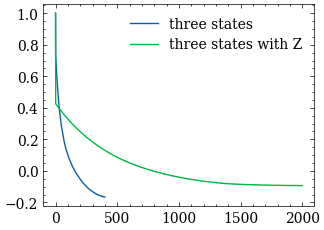

In [12]:
plt.plot(np.arange(tau_max_three), acfs_three.mean(axis=0), label="three states")
plt.plot(np.arange(tau_max_threeZ), acfs_threeZ.mean(axis=0), label="three states with Z")
#plt.fill_between(np.arange(tau_max_three), acfs_three.mean(axis=0)-acfs_three.std(axis=0) / np.sqrt(ntrajs),
#                                           acfs_three.mean(axis=0)+acfs_three.std(axis=0) / np.sqrt(ntrajs), alpha=0.4)
#plt.fill_between(np.arange(tau_max_four),  acfs_four.mean(axis=0)- acfs_four.std(axis=0) / np.sqrt(ntrajs),
#                                           acfs_four.mean(axis=0)+ acfs_four.std(axis=0) / np.sqrt(ntrajs), alpha=0.4)
plt.legend()
plt.show()

### Compare free energies

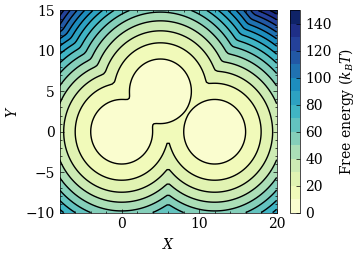

(100, 100, 100) (100, 100, 100) (100, 100, 100) (100, 100, 100)


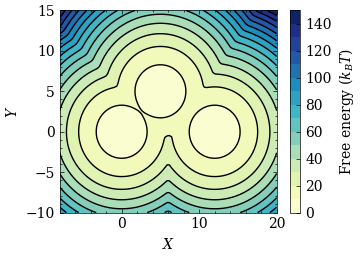

In [14]:
# 3 minima
def target_energy(xdata, ydata):
    gauss1 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((xdata)**2 + (ydata)**2))
    gauss2 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((xdata-5)**2 + (ydata-5)**2))
    gauss3 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((xdata-12)**2 + (ydata)**2)) # asymmetry along x!
    energy = -np.log(1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3)
    return energy
xdata, ydata = np.meshgrid(np.linspace(-8,20,100), np.linspace(-10,15,100), copy=True, sparse=False, indexing='xy')
free_ene = target_energy(xdata, ydata)

plt.contourf(xdata, ydata, free_ene, cmap='YlGnBu', levels=14)#, norm="log")
plt.colorbar(label='Free energy ($k_B T$)')
plt.contour(xdata, ydata, free_ene, colors='k', linewidths=1, levels=14)#, norm="log")
#plt.xlim([0, np.pi])
#plt.ylim([0, np.pi])
plt.xlabel("$X$")
plt.ylabel("$Y$")
#plt.savefig('./figures/free_eng_3minima.pdf', transparent=True, dpi=300)
plt.show()

# 4 minima
def target_energy_3minimaZ(xdata, ydata, zdata):
    gauss1 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*(xdata**2 + ydata**2 + zdata**2))
    gauss2 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((xdata-5)**2 + (ydata-5)**2 + (zdata-5)**2))
    gauss3 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((xdata-12)**2 + ydata**2 + (zdata-16)**2))
    energy = -np.log(1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3)
    return energy
xdata, ydata, zdata = np.meshgrid(np.linspace(-8,20,100), np.linspace(-10,15,100), np.linspace(-10,23,100), copy=True, sparse=False, indexing='xy')
free_ene = target_energy_3minimaZ(xdata, ydata, zdata)

print(xdata.shape, ydata.shape, zdata.shape, free_ene.shape)
free_ene_proj = -np.log(np.mean(np.exp(-free_ene), axis=-1))

plt.contourf(xdata[:,:,0], ydata[:,:,0], free_ene_proj, cmap='YlGnBu', levels=14)#, norm="log")
plt.colorbar(label='Free energy ($k_B T$)')
plt.contour(xdata[:,:,0], ydata[:,:,0], free_ene_proj, colors='k', linewidths=1, levels=14)#, norm="log")
#plt.xlim([0, np.pi])
#plt.ylim([0, np.pi])
plt.xlabel("$X$")
plt.ylabel("$Y$")
#plt.savefig('./figures/free_eng_3minima.pdf', transparent=True, dpi=300)
plt.show()

# THREE MINIMA

### 1) Transfer entropy

In [2]:
k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int) * 10
print(taus.shape)
seeds = np.arange(20)

(19,)


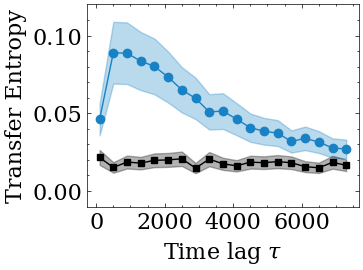

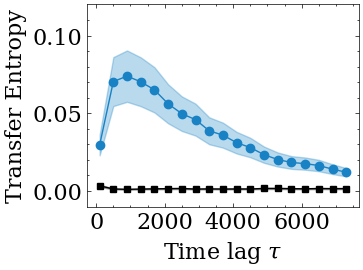

In [14]:
plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_te_check_with_4_minima/seed{seed}_N{N}_k{k}.p","rb"))
    )

# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.12])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_cont.pdf', transparent=True, dpi=300)
plt.show()

# discrete
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_discrete.mean(axis=0), TEs_X_to_Y_discrete.mean(axis=0) / np.sqrt(TEs_X_to_Y_discrete.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_discrete.mean(axis=0), TEs_Y_to_X_discrete.mean(axis=0) / np.sqrt(TEs_Y_to_X_discrete.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.12])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_discr.pdf', transparent=True, dpi=300)
plt.show()

Only continuous, no markers

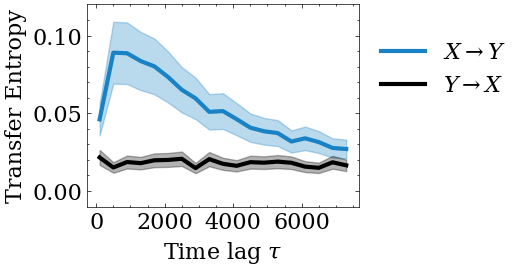

In [15]:
plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_discrete[iseed], TEs_Y_to_X_discrete[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far/pickles_te_check_with_4_minima/seed{seed}_N{N}_k{k}.p","rb"))
    )

# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, '-', color=colors[0], linewidth=3, label="$X\\rightarrow Y$")
plt.plot(taus, avg_Y_to_X, '-', color=colors[1], linewidth=3, label="$Y\\rightarrow X$")
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.12])
plt.legend(loc=(1.05,0.5))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_cont_nomarkers.pdf', transparent=True, dpi=300)
plt.show()

# THREE MINIMA WITH Z

### 1) Transfer entropy

In [2]:
k = 7
N = 2500
taus = np.arange(10,4810+100,200,dtype=int) * 10
print(taus.shape)
seeds = np.arange(20)

(25,)


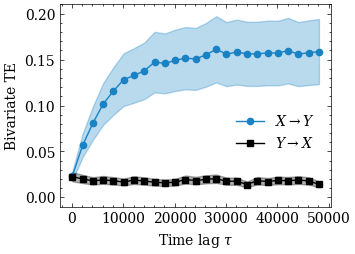

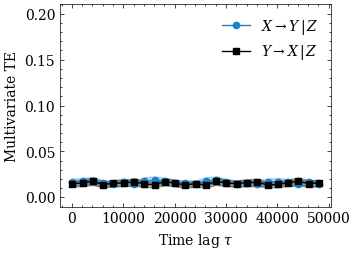

In [17]:
#plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0], markersize=4.5, label="$X\\rightarrow Y$")
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=4, label="$Y\\rightarrow X$")
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Bivariate TE")
plt.ylim([-0.01, 0.21])
plt.legend(loc=(0.63,0.25))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont.pdf', transparent=True, dpi=300)
plt.show()

# conditioning
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_givenZ.mean(axis=0), TEs_X_to_Y_givenZ.mean(axis=0) / np.sqrt(TEs_X_to_Y_givenZ.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_givenZ.mean(axis=0), TEs_Y_to_X_givenZ.mean(axis=0) / np.sqrt(TEs_Y_to_X_givenZ.shape[0])
plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0], markersize=4.5,  label="$X\\rightarrow Y\, |\, Z$")
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=4, label="$Y\\rightarrow X\, |\, Z$")
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Multivariate TE")
plt.ylim([-0.01, 0.21])
plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont_conditional_on_Z.pdf', transparent=True, dpi=300)
plt.show()

Only bivariate (noZ), no markers

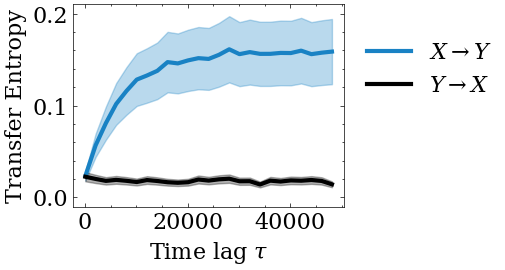

In [18]:
plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
plt.plot(taus, avg_X_to_Y, '-', color=colors[0], linewidth=3, label="$X\\rightarrow Y$")
plt.plot(taus, avg_Y_to_X, '-', color=colors[1], linewidth=3, label="$Y\\rightarrow X$")
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.21])
plt.legend(loc=(1.05,0.5))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont_nomarkers.pdf', transparent=True, dpi=300)
plt.show()

### Version for presentation only
NB execute before running other blocks

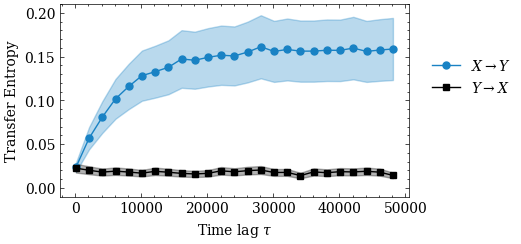

In [7]:
TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

fig, ax = plt.subplots(1,figsize=(4.5,2.5))

ax.plot(taus, avg_X_to_Y, 'o-', color=colors[0], linewidth=1, markersize=5, label="$X\\rightarrow Y$")
ax.plot(taus, avg_Y_to_X, 's-', color=colors[1], linewidth=1, markersize=4, label="$Y\\rightarrow X$")
ax.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
ax.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#ax.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
ax.set_xlabel("Time lag $\\tau$")
ax.set_ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.21])
ax.legend(loc=(1.05,0.5))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont_SLIDES.pdf', transparent=True, dpi=300)
plt.show()

### FOR SI: Multivariate TE Z->X | Y and Z->Y | X

In [ ]:
k = 7
N = 2500
taus = np.arange(10,4810+100,200,dtype=int) * 10
print(taus.shape)
seeds = np.arange(20)

(19,)


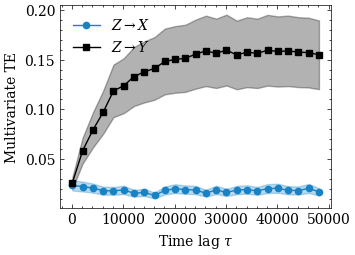

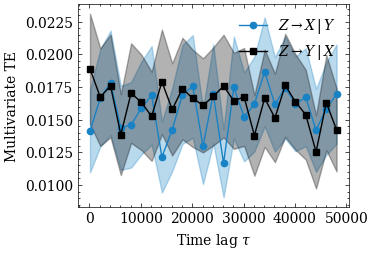

In [23]:
TEs_Z_to_X = np.zeros((len(seeds),len(taus)))
TEs_Z_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Z_to_X_givenY = np.zeros((len(seeds),len(taus)))
TEs_Z_to_Y_givenX = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_Z_to_X[iseed], TEs_Z_to_Y[iseed], TEs_Z_to_X_givenY[iseed], TEs_Z_to_Y_givenX[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/pickles_te_multiv_ZtoXY/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_Z_to_X, err_Z_to_X = TEs_Z_to_X.mean(axis=0), TEs_Z_to_X.mean(axis=0) / np.sqrt(TEs_Z_to_X.shape[0])
avg_Z_to_Y, err_Z_to_Y = TEs_Z_to_Y.mean(axis=0), TEs_Z_to_Y.mean(axis=0) / np.sqrt(TEs_Z_to_Y.shape[0])

plt.plot(taus, avg_Z_to_X, 'o-', color=colors[0], markersize=4.5,  label="$Z\\rightarrow X$")
plt.plot(taus, avg_Z_to_Y, 's-', color=colors[1], markersize=4, label="$Z\\rightarrow Y$")
plt.fill_between(taus, avg_Z_to_X-err_Z_to_X, avg_Z_to_X+err_Z_to_X, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Z_to_Y-err_Z_to_Y, avg_Z_to_Y+err_Z_to_Y, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Multivariate TE")
#plt.ylim([-0.01, 0.21])
plt.legend()
#plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont_conditional_on_Z.pdf', transparent=True, dpi=300)
plt.show()

# multivariate
avg_Z_to_X, err_Z_to_X = TEs_Z_to_X_givenY.mean(axis=0), TEs_Z_to_X_givenY.mean(axis=0) / np.sqrt(TEs_Z_to_X_givenY.shape[0])
avg_Z_to_Y, err_Z_to_Y = TEs_Z_to_Y_givenX.mean(axis=0), TEs_Z_to_Y_givenX.mean(axis=0) / np.sqrt(TEs_Z_to_Y_givenX.shape[0])

plt.plot(taus, avg_Z_to_X, 'o-', color=colors[0], markersize=4.5,  label="$Z\\rightarrow X\, |\, Y$")
plt.plot(taus, avg_Z_to_Y, 's-', color=colors[1], markersize=4, label="$Z\\rightarrow Y\, |\, X$")
plt.fill_between(taus, avg_Z_to_X-err_Z_to_X, avg_Z_to_X+err_Z_to_X, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Z_to_Y-err_Z_to_Y, avg_Z_to_Y+err_Z_to_Y, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Multivariate TE")
#plt.ylim([-0.01, 0.21])
plt.legend()
#plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z/figures/TE_3minima_withZ_cont_conditional_on_Z.pdf', transparent=True, dpi=300)
plt.show()